# Diagnostic Breast Cancer Dataset

# Breast Cancer Diagnostic Classification with PyTorch

This notebook builds a simple feedforward neural network using PyTorch to classify 
breast cancer tumours as **malignant** or **benign** based on features extracted from 
digitised images of fine needle aspirate (FNA) biopsies.

## Dataset
The [Wisconsin Diagnostic Breast Cancer (WDBC)](https://www.kaggle.com/datasets/yasserh/breast-cancer-dataset) 
dataset contains **569 samples** and **30 numerical features** describing characteristics 
of cell nuclei, such as radius, texture, perimeter, area, and smoothness — each recorded 
as mean, standard error, and worst value.

## Objective
Train a binary classifier to distinguish:
- `0` → Benign
- `1` → Malignant

## Approach
- Data preprocessing with `StandardScaler` (fit on train only)
- Simple `nn.Sequential` model with one hidden layer
- Training with `CrossEntropyLoss` and `Adam` optimiser
- Evaluation via loss/accuracy curves and a confusion matrix

In [547]:
import random
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn  # nn contains all of PyTorch's building blocks for neural networks
import torch.optim as optim  # Import the entire optim module
from shap import Explanation
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [426]:
# Check PyTorch version
print(f"PyTorch version: {torch.__version__}")
print(f"pandas version:{pd.__version__}")
print(f"numpy version:{np.__version__}")
print(f"matplotlib version:{plt.matplotlib.__version__}")

PyTorch version: 2.3.0
pandas version:2.2.2
numpy version:1.26.4
matplotlib version:3.9.2


# Load data

In [428]:
path = Path(kagglehub.dataset_download("ahmeduzaki/diagnostic-breast-cancer-dataset"))

csv_path = path / "Diagnostic Breast Cancer Dataset.csv"

# Inspecting the data

In [430]:
df = pd.read_csv(csv_path)

df.head()

,ID,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension,Diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,Malignant
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,Malignant
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,Malignant
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,Malignant
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,Malignant


In [431]:
# Checking shape
df.shape

(569, 32)

In [432]:
# Check for missing values
df.isna().sum()

ID                         0
Mean Radius                0
Mean Texture               0
Mean Perimeter             0
Mean Area                  0
Mean Smoothness            0
Mean Compactness           0
Mean Concavity             0
Mean Concave Points        0
Mean Symmetry              0
Mean Fractal Dimension     0
Radius SE                  0
Texture SE                 0
Perimeter SE               0
Area SE                    0
Smoothness SE              0
Compactness SE             0
Concavity SE               0
Concave Points SE          0
Symmetry SE                0
Fractal Dimension SE       0
Worst Radius               0
Worst Texture              0
Worst Perimeter            0
Worst Area                 0
Worst Smoothness           0
Worst Compactness          0
Worst Concavity            0
Worst Concave Points       0
Worst Symmetry             0
Worst Fractal Dimension    0
Diagnosis                  0
dtype: int64

In [433]:
# Checking summary statistics
df.describe()

,ID,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [434]:
# Checking column names
df.columns

Index(['ID', 'Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area',
       'Mean Smoothness', 'Mean Compactness', 'Mean Concavity',
       'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension',
       'Radius SE', 'Texture SE', 'Perimeter SE', 'Area SE', 'Smoothness SE',
       'Compactness SE', 'Concavity SE', 'Concave Points SE', 'Symmetry SE',
       'Fractal Dimension SE', 'Worst Radius', 'Worst Texture',
       'Worst Perimeter', 'Worst Area', 'Worst Smoothness',
       'Worst Compactness', 'Worst Concavity', 'Worst Concave Points',
       'Worst Symmetry', 'Worst Fractal Dimension', 'Diagnosis'],
      dtype='object')

In [435]:
# Checking labels
df.Diagnosis.unique()

array(['Malignant', 'Benign'], dtype=object)

## Mapping the diagnosis (labels) for classification.

In [437]:
labels = df["Diagnosis"].map({"Benign": 0, "Malignant": 1})
labels

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: Diagnosis, Length: 569, dtype: int64

## Selecting features and sanity check

In [439]:
features = df.drop(["ID", "Diagnosis"], axis=1)
features

,Mean Radius,Mean Texture,Mean Perimeter,Mean Area,Mean Smoothness,Mean Compactness,Mean Concavity,Mean Concave Points,Mean Symmetry,Mean Fractal Dimension,...,Worst Radius,Worst Texture,Worst Perimeter,Worst Area,Worst Smoothness,Worst Compactness,Worst Concavity,Worst Concave Points,Worst Symmetry,Worst Fractal Dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [550]:
# Sanity checks
X = torch.tensor(features.values, dtype=torch.float32)
y = torch.tensor(labels.values, dtype=torch.long)
X, y

(tensor([[1.7990e+01, 1.0380e+01, 1.2280e+02,  ..., 2.6540e-01, 4.6010e-01,
          1.1890e-01],
         [2.0570e+01, 1.7770e+01, 1.3290e+02,  ..., 1.8600e-01, 2.7500e-01,
          8.9020e-02],
         [1.9690e+01, 2.1250e+01, 1.3000e+02,  ..., 2.4300e-01, 3.6130e-01,
          8.7580e-02],
         ...,
         [1.6600e+01, 2.8080e+01, 1.0830e+02,  ..., 1.4180e-01, 2.2180e-01,
          7.8200e-02],
         [2.0600e+01, 2.9330e+01, 1.4010e+02,  ..., 2.6500e-01, 4.0870e-01,
          1.2400e-01],
         [7.7600e+00, 2.4540e+01, 4.7920e+01,  ..., 0.0000e+00, 2.8710e-01,
          7.0390e-02]]),
 tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
         0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
         1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
         0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 

In [552]:
print(f"X shape: {X.shape}")  # e.g. torch.Size([569, 30])
print(f"y shape: {y.shape}")  # e.g. torch.Size([569])
print(f"Classes: {y.unique()}")  # tensor([0, 1])

X shape: torch.Size([569, 30])
y shape: torch.Size([569])
Classes: tensor([0, 1])


# Data preparation and normalisation

In [554]:
# 1. Data prep

# Create a random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    features.to_numpy(),
    labels.to_numpy(),
    test_size=0.2,
    random_state=SEED,
    stratify=labels.to_numpy(),
)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit only on train
X_test = scaler.transform(X_test)  # transform test with train stats

# Tensor conversion
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# Build a model

In [556]:
# 2. Model
class Classifier(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        return self.model(x)

In [558]:
n_features = X_train.shape[1]
n_classes = len(torch.unique(y_train))
model = Classifier(n_features, n_classes)

# Loss and optimiser

In [587]:
# 3. Loss & optimiser
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training Loop

Epoch: 0 | Loss: 0.80969, Accuracy: 34.73% | Test loss: 0.79447, Test acc: 34.21%
Epoch: 10 | Loss: 0.57322, Accuracy: 80.22% | Test loss: 0.56129, Test acc: 78.07%
Epoch: 20 | Loss: 0.40516, Accuracy: 91.43% | Test loss: 0.39718, Test acc: 92.11%
Epoch: 30 | Loss: 0.29221, Accuracy: 93.41% | Test loss: 0.28921, Test acc: 94.74%
Epoch: 40 | Loss: 0.22047, Accuracy: 94.95% | Test loss: 0.22100, Test acc: 94.74%
Epoch: 50 | Loss: 0.17519, Accuracy: 95.60% | Test loss: 0.17787, Test acc: 94.74%
Epoch: 60 | Loss: 0.14565, Accuracy: 96.92% | Test loss: 0.14958, Test acc: 96.49%
Epoch: 70 | Loss: 0.12530, Accuracy: 97.36% | Test loss: 0.13024, Test acc: 97.37%
Epoch: 80 | Loss: 0.11048, Accuracy: 97.80% | Test loss: 0.11659, Test acc: 98.25%
Epoch: 90 | Loss: 0.09925, Accuracy: 98.02% | Test loss: 0.10665, Test acc: 98.25%


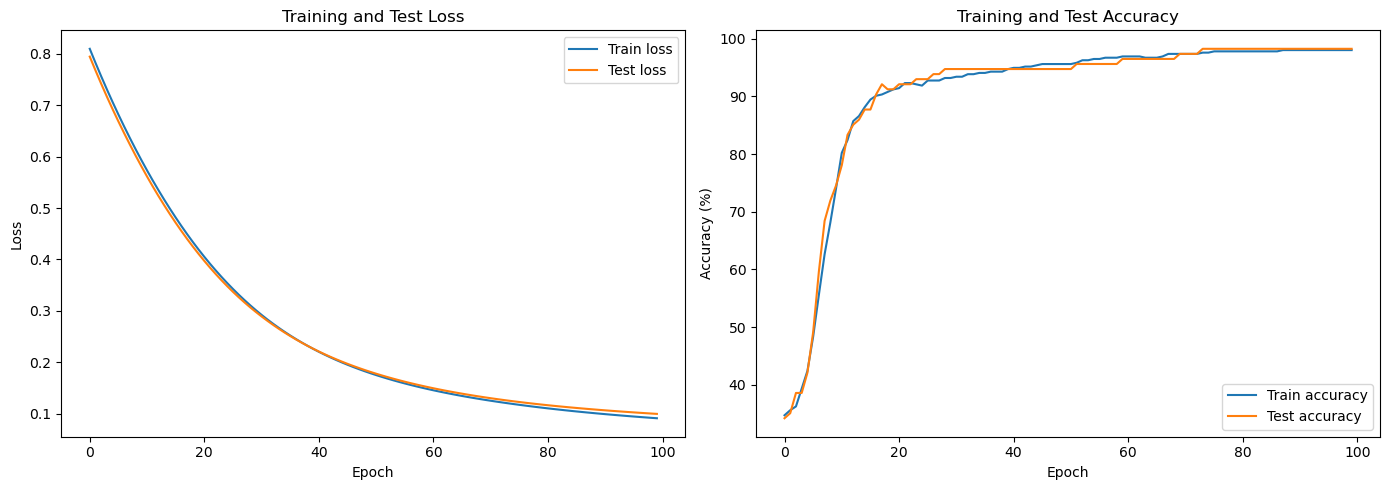

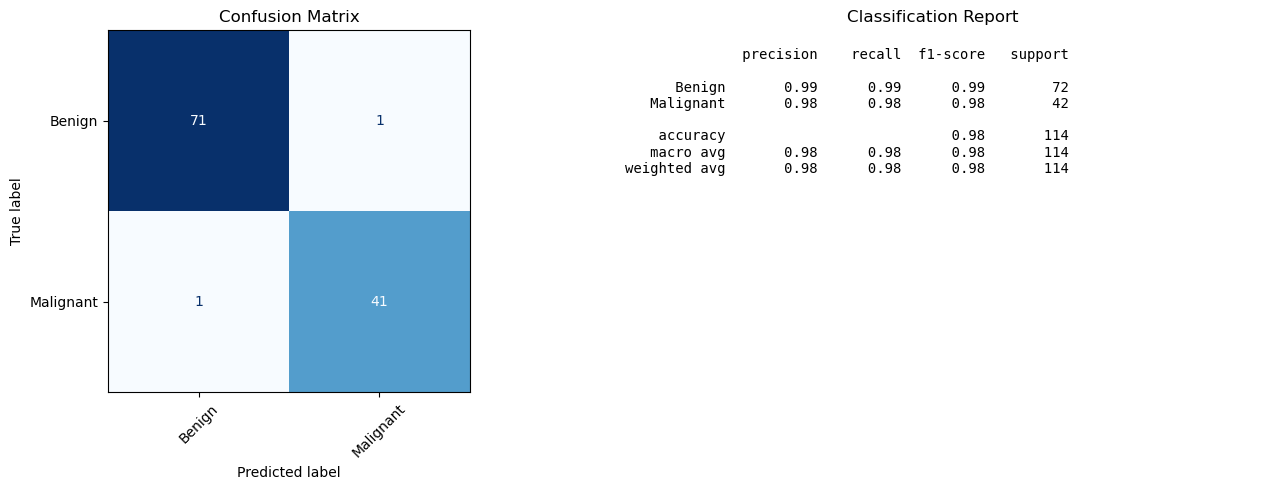

In [562]:
# 4. Training loop
# Initialise tracking lists
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

EPOCHS = 100

for epoch in range(EPOCHS):
    # Training
    model.train()
    optimizer.zero_grad()
    logits = model(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()

    acc = (logits.argmax(dim=1) == y_train).float().mean() * 100

    # Evaluation
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_loss = criterion(test_logits, y_test)
        test_acc = (test_logits.argmax(dim=1) == y_test).float().mean() * 100

    # Track
    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accuracies.append(acc.item())
    test_accuracies.append(test_acc.item())

    if epoch % 10 == 0:
        print(
            f"Epoch: {epoch} | "
            f"Loss: {loss:.5f}, Accuracy: {acc:.2f}% | "
            f"Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%"
        )

# Plotting
# --- Figure 1: Training curves ---
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 5))

axes1[0].plot(train_losses, label="Train loss")
axes1[0].plot(test_losses, label="Test loss")
axes1[0].set_xlabel("Epoch")
axes1[0].set_ylabel("Loss")
axes1[0].set_title("Training and Test Loss")
axes1[0].legend()

axes1[1].plot(train_accuracies, label="Train accuracy")
axes1[1].plot(test_accuracies, label="Test accuracy")
axes1[1].set_xlabel("Epoch")
axes1[1].set_ylabel("Accuracy (%)")
axes1[1].set_title("Training and Test Accuracy")
axes1[1].legend()

plt.tight_layout()
plt.show()
print()

# --- Figure 2: Evaluation ---
model.eval()
with torch.inference_mode():
    preds = model(X_test).argmax(dim=1).numpy()
    true = y_test.numpy()

class_names = ["Benign", "Malignant"]

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", xticks_rotation=45, ax=axes2[0], colorbar=False)
axes2[0].set_title("Confusion Matrix")

report = classification_report(true, preds, target_names=class_names)
axes2[1].text(
    0.05,
    0.95,
    report,
    transform=axes2[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
)
axes2[1].set_title("Classification Report")
axes2[1].axis("off")

plt.tight_layout()
plt.show()
# print(report)

# XAI — SHAP
SHAP (SHapley Additive exPlanations) is a framework for explaining machine 
learning model predictions, grounded in game theory. It assigns each feature 
a SHAP value representing its contribution to a specific prediction relative 
to a baseline (the expected model output), and these values are mathematically 
consistent, locally accurate, and fairly distributed across all features.

SHAP offers several plot types suited to different levels of explanation — 
global (across all samples) or local (a single prediction). The three used 
here are summarised below.

| Plot | Level | X-axis | Colour | Best for |
|---|---|---|---|---|
| `summary_plot(bar)` | Global | Mean absolute SHAP value | None | Ranking features by overall importance |
| `plots.beeswarm` | Global | SHAP value per sample | Feature value (red=high, blue=low) | Direction + heterogeneity of each feature's effect |
| `plots.waterfall` | Local (1 sample) | SHAP value | Positive/negative contribution | Explaining a single model prediction |

## Global Feature Importance
This section looks at the model's behaviour across all test samples, asking which features matter most and how they influence predictions on average.

### SHAP Summary Plot
`summary_plot (bar)` gives a global overview of feature importance by plotting the mean absolute SHAP value for each feature across all samples. It tells you which features the model relies on most on average, but collapses all directional and sample-level information into a single bar per feature.

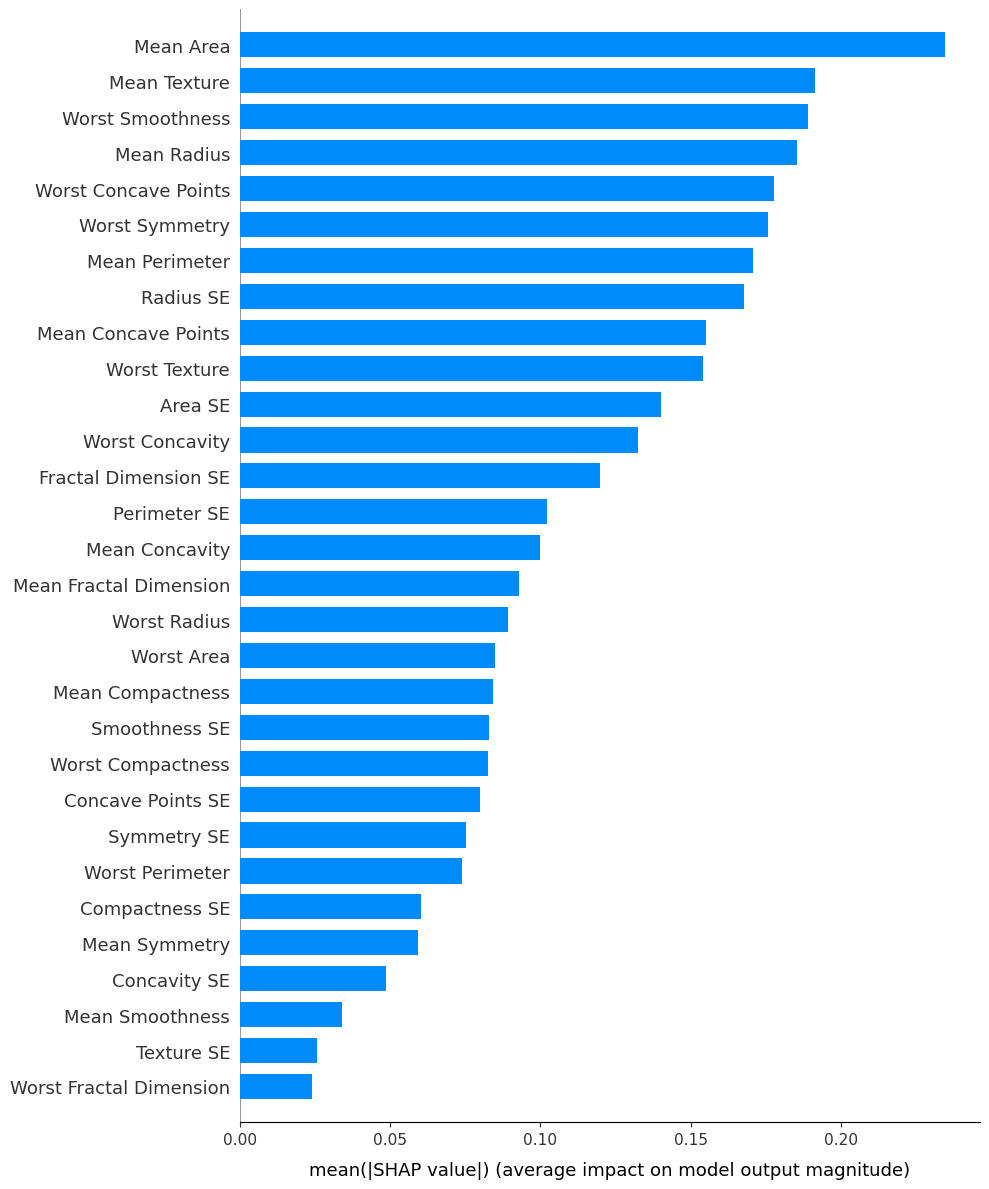

In [623]:
# 5. SHAP Feature Importance
# Mean absolute SHAP value, i.e. Ranking features by overall importance
model.eval()

# Background sample: small subset of training data
background = X_train[:50]

# Explainer and SHAP values on test set
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(X_test)

sv = shap_values[:, :, 1]  # SHAP: 3D array (samples, features, classes)

rng = np.random.default_rng(42)

shap.summary_plot(
    sv,
    X_test.numpy(),
    feature_names=features.columns.tolist(),
    plot_type="bar",
    max_display=30,
    show=False,
    rng=rng,
)
fig = plt.gcf()
fig.set_size_inches(10, 12)
plt.xlabel("mean(|SHAP value|) (average impact on model output magnitude)", labelpad=10)
plt.tight_layout()
plt.show()

## SHAP Beeswarm
`plots.beeswarm` is the richest global view, showing one dot per sample per feature. The x-axis position encodes the SHAP value (direction and magnitude of impact), while the dot colour encodes the actual feature value (red = high, blue = low). This lets you see not just which features matter, but how they matter and whether their effect is consistent or heterogeneous across samples.

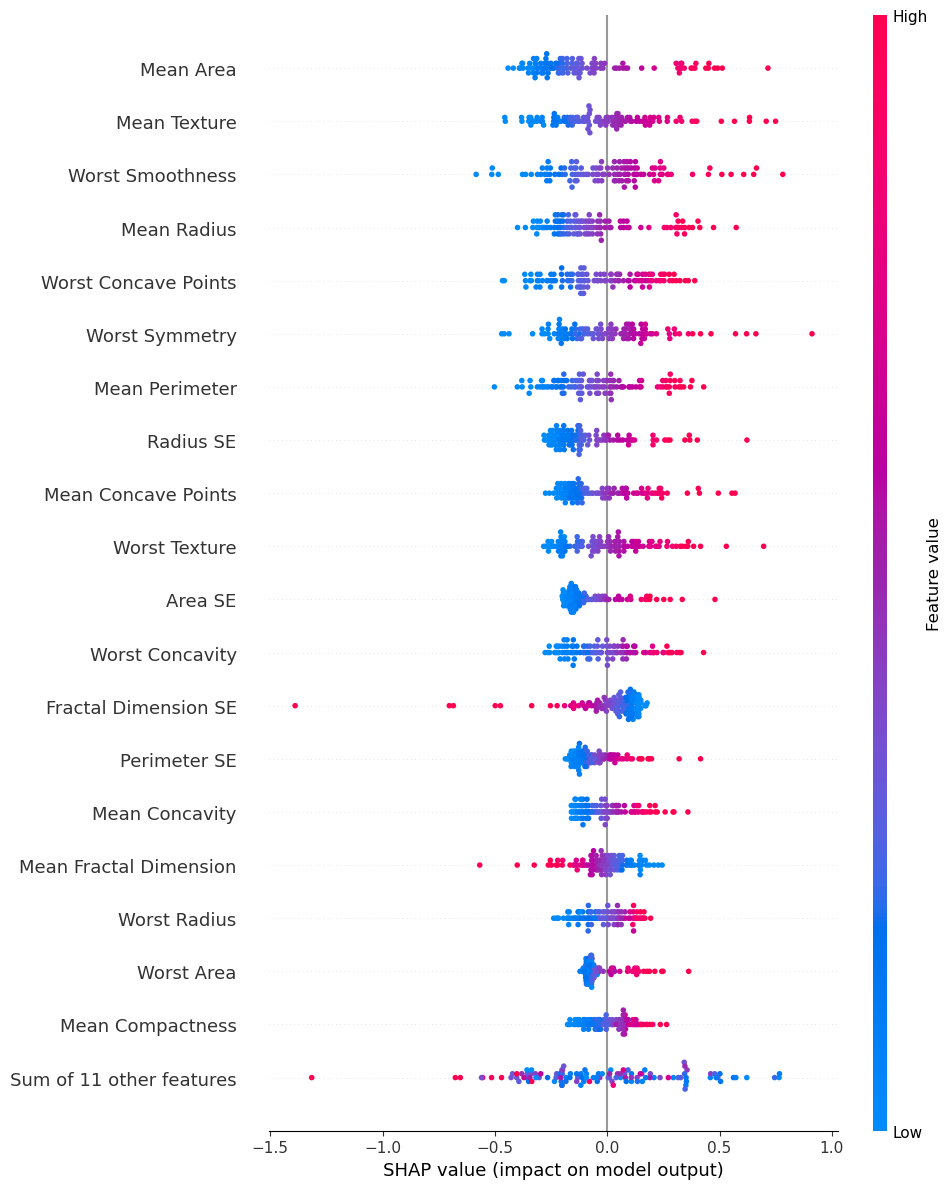

In [582]:
# 7. SHAP Beeswarm
# SHAP value per sample, i.e. Understanding direction + heterogeneity of each feature's effect

shap.plots.beeswarm(exp, max_display=20, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 12)
plt.tight_layout()
plt.show()

## Single-Sample Explanation
This section zooms into individual predictions, showing how the model arrived at a specific output for one benign and one malignant case. This is useful for understanding the reasoning behind a particular decision rather than average behaviour across the dataset.

### SHAP Waterfall
`plots.waterfall` is a local explanation for a single sample, showing how each feature pushed the model's prediction up or down from the baseline to the final output. It is the go-to plot when you want to interrogate one specific prediction in detail, such as a misclassification or a borderline case.

In [621]:
# 6. SHAP Waterfall
# SHAP values Positive/negative contributions, i.e. Explaining why the model made a specific prediction

exp = Explanation(
    values=sv,  # (n_samples, n_features)
    base_values=explainer.expected_value[1],  # scalar or array
    data=X_test.numpy(),  # actual feature values
    feature_names=features.columns.tolist(),
)

In [568]:
# Select one representative sample per class - (Benign:0 ; Malignant:1)
benign_idx = (y_test == 0).nonzero()[0].item()
malignant_idx = (y_test == 1).nonzero()[0].item()

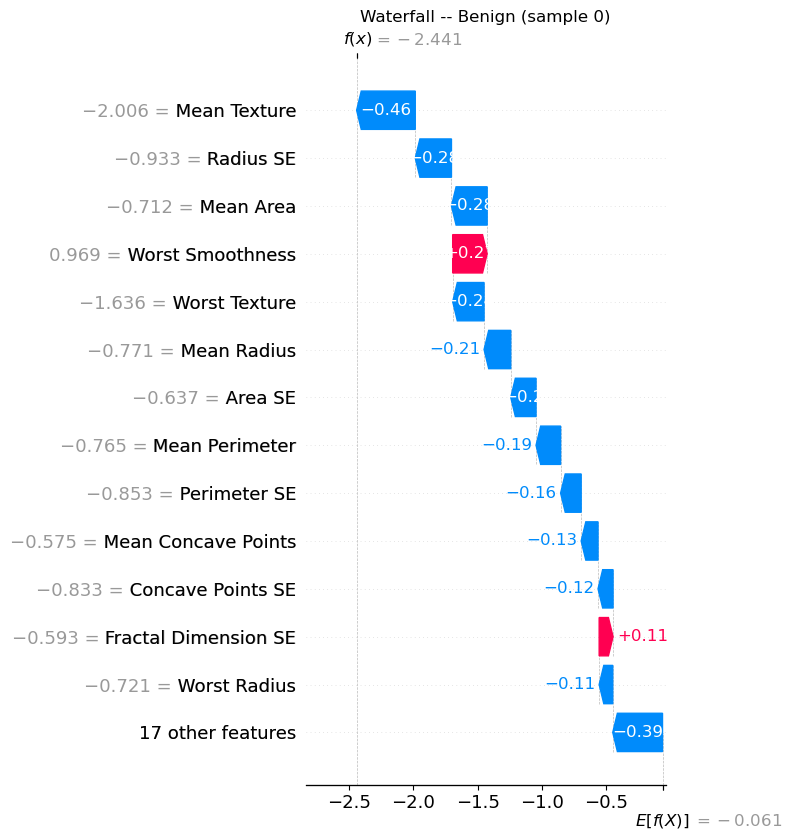

In [570]:
# Benign example
shap.plots.waterfall(exp[benign_idx], max_display=14, show=False)
plt.title(f"Waterfall -- Benign (sample {benign_idx})")
plt.tight_layout()
plt.show()

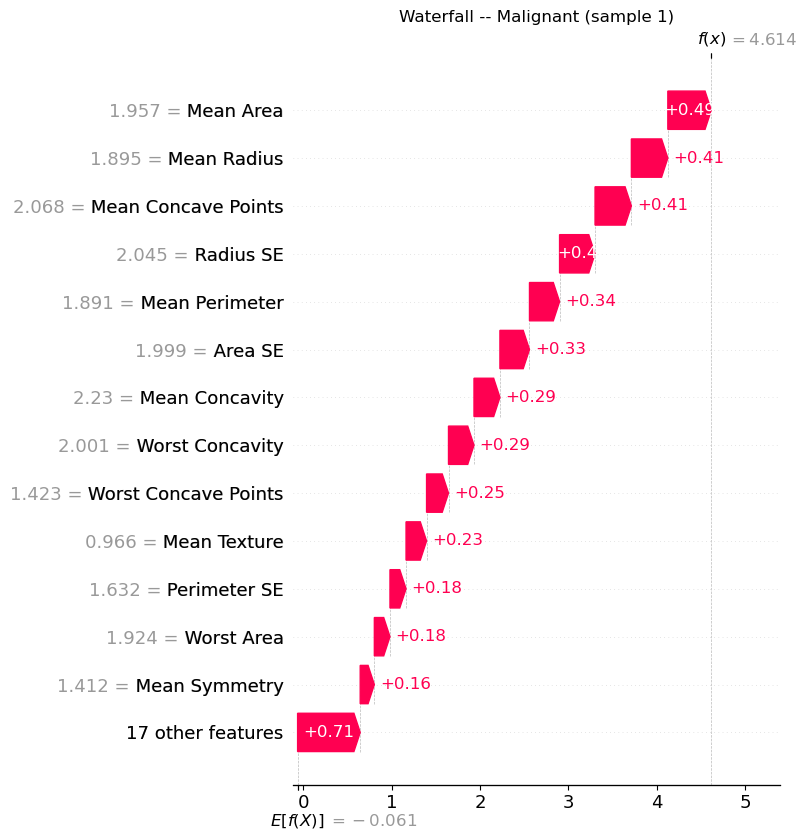

In [572]:
# Malignant example
shap.plots.waterfall(exp[malignant_idx], max_display=14, show=False)
plt.title(f"Waterfall -- Malignant (sample {malignant_idx})")
plt.tight_layout()
plt.show()

## Feature-Level Relationships
This section examines how specific features relate to their SHAP values across all samples. Unlike the bar plot or beeswarm, which show many features at once, the scatter plot focuses on one feature at a time and makes the direction and shape of its influence on the prediction explicit.

### SHAP Scatter: Mean Area
`plots.scatter` plots a single feature's actual value on the x-axis against its SHAP value on the y-axis, one dot per sample. A positive SHAP value means that feature pushed the prediction toward malignant; negative means toward benign. Mean Area shows a clean positive relationship: larger nuclei consistently push the model toward a malignant prediction, with no ambiguity in direction across the sample range.

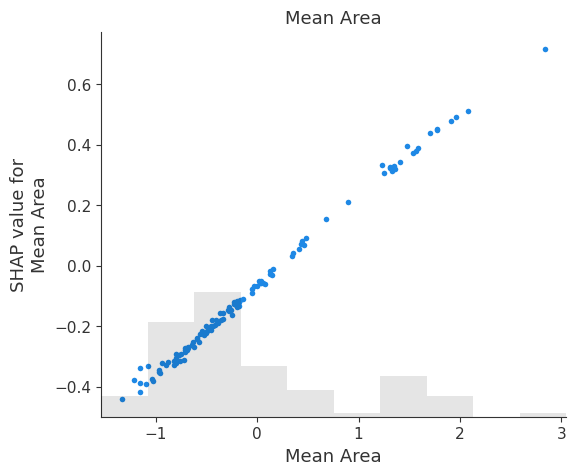

In [657]:
shap.plots.scatter(exp[:, "Mean Area"],
                   title="Mean Area")


### SHAP Scatter: Worst Symmetry
Worst Symmetry also shows a positive monotonic relationship: higher nuclear asymmetry in the worst-case measurement pushes the prediction toward malignant. The relationship is consistent across samples, with two outliers at high symmetry values worth noting.

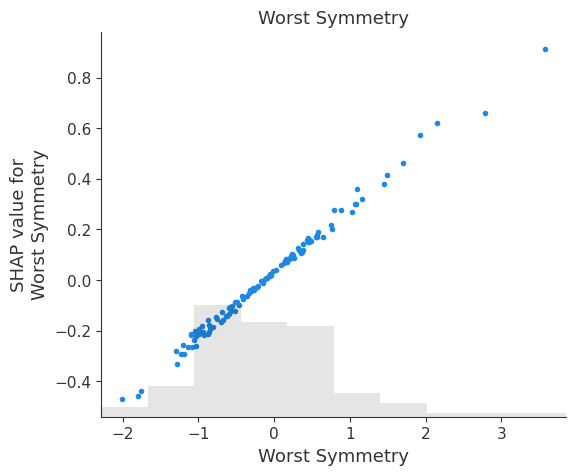

In [687]:
shap.plots.scatter(exp[:, "Worst Symmetry"],
                   title="Worst Symmetry")


### SHAP Scatter: Fractal Dimension SE
Fractal Dimension SE shows the opposite pattern: higher values push the prediction toward benign. This is the standard error of the fractal dimension measurement, so high values reflect inconsistency in boundary irregularity across the nucleus rather than irregularity itself. The model treats this as a benign signal. Note the single outlier at approximately 7 on the x-axis with a SHAP value near -1.4, sitting well outside the training distribution.

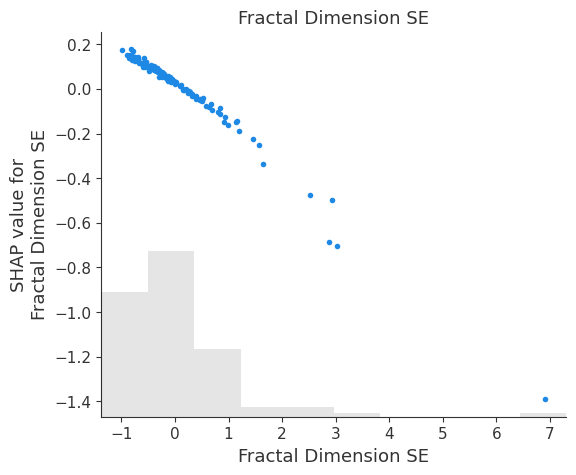

In [693]:
shap.plots.scatter(exp[:, "Fractal Dimension SE"],
                   title="Fractal Dimension SE")


# Conclusion

This notebook builds a feedforward neural network in PyTorch to classify breast cancer
tumours as benign or malignant from tabular morphological features extracted from FNA
biopsy images.

The model correctly classified 112 out of 114 held-out samples, achieving 98% accuracy.
Only one malignant case was missed out of 42, giving a malignant recall of 0.98. In a
diagnostic context, missed malignancies matter more than false alarms, so recall on the
malignant class is the number to watch.

SHAP was used to understand what the model is actually doing. Mean Area came out as the
feature with the largest influence on predictions, followed by Mean Texture, Mean Radius,
and Worst Concave Points. This is consistent with how pathologists read FNA slides: larger
nuclei with irregular shapes tend to indicate malignancy. Worth noting that Mean Area, Mean
Radius, and Mean Perimeter all measure variations of the same thing, so their individual
SHAP values should be read together rather than separately.

The beeswarm plot confirmed this pattern holds across samples, with high values of the top
features reliably pushing the model toward a malignant prediction. The waterfall plots
applied the same logic to individual cases, breaking down exactly which features drove each
prediction for one benign and one malignant sample.

The scatter plots revealed that most features show clean monotonic relationships with the
prediction: Mean Area and Worst Symmetry push toward malignant as their values increase,
while Fractal Dimension SE and Mean Fractal Dimension push toward benign. The relative
simplicity of these relationships is consistent with the model's strong performance on a
small dataset. One outlier in Fractal Dimension SE sits well outside the training
distribution and warrants attention if the model is applied to new data.

**Potential next steps:**
- Compare against logistic regression and random forest baselines
- Add k-fold cross-validation for a more robust performance estimate
- Tune the decision threshold to reduce missed malignancies further